<a href="https://colab.research.google.com/github/cewgs/Computer-Vision-Project/blob/main/computer_vision_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computer Vision- Recognize Facial Emotions**
##### This project aims to build a computer vision model to predict 7 different emotions on human faces using transfer learning.


In [ ]:
!pip install mlflow

In [87]:
import mlflow
import copy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torchvision import models,  transforms
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import gradio as gr

In [88]:
import kagglehub
path = kagglehub.dataset_download("shuvoalok/raf-db-dataset")

Using Colab cache for faster access to the 'raf-db-dataset' dataset.


In [89]:
for root, dirs, files in os.walk(path):
    print(root, files[:5])

/kaggle/input/raf-db-dataset ['test_labels.csv', 'train_labels.csv']
/kaggle/input/raf-db-dataset/DATASET []
/kaggle/input/raf-db-dataset/DATASET/test []
/kaggle/input/raf-db-dataset/DATASET/test/7 ['test_2941_aligned.jpg', 'test_2717_aligned.jpg', 'test_2499_aligned.jpg', 'test_2724_aligned.jpg', 'test_2935_aligned.jpg']
/kaggle/input/raf-db-dataset/DATASET/test/2 ['test_2286_aligned.jpg', 'test_2285_aligned.jpg', 'test_2270_aligned.jpg', 'test_2244_aligned.jpg', 'test_2280_aligned.jpg']
/kaggle/input/raf-db-dataset/DATASET/test/5 ['test_0085_aligned.jpg', 'test_1042_aligned.jpg', 'test_1133_aligned.jpg', 'test_0336_aligned.jpg', 'test_1198_aligned.jpg']
/kaggle/input/raf-db-dataset/DATASET/test/3 ['test_1511_aligned.jpg', 'test_2315_aligned.jpg', 'test_0774_aligned.jpg', 'test_2372_aligned.jpg', 'test_1018_aligned.jpg']
/kaggle/input/raf-db-dataset/DATASET/test/1 ['test_2130_aligned.jpg', 'test_1969_aligned.jpg', 'test_0431_aligned.jpg', 'test_1080_aligned.jpg', 'test_0043_aligned.jp

In [90]:
df = pd.read_csv('/kaggle/input/raf-db-dataset/train_labels.csv')
print(df.head())

                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5


# Data Loader

In [91]:
class RAFdataset(Dataset):
    """
    Dataset class for loading RAF-DB images and labels.
    """

    def __init__(self, root_dir, split="train", transform=None):
        """
        Initialize dataset paths and image samples.

        Args:
            root_dir: Path to RAFDB dataset.
            split: Dataset split in train and test.
            transform: Optional image transformations.
        """
        self.transform = transform
        self.samples = []

        split_dir = os.path.join(root_dir, split)

        for class_folder in sorted(os.listdir(split_dir)):
            label = int(class_folder) - 1
            folder_path = os.path.join(split_dir, class_folder)

            for filename in os.listdir(folder_path):
                if filename.endswith(".jpg"):
                    full_path = os.path.join(folder_path, filename)
                    self.samples.append((full_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """load and return one image/label pair"""
        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Preprocessor

In [92]:
class Preprocessor:
    """
    Preprocessor class for image transformations.
    """
    def __init__(self, augment=False):
        """
        Initialize image transformations.

        Args:
            augment:  for image augmentation.

        Notes:
        Values are from ImageNet database
        https://docs.pytorch.org/vision/stable/models.html
        """

        imagenet_mean = [0.485, 0.456, 0.406]
        imagenet_std  = [0.229, 0.224, 0.225]

        if augment:
            # different transformations
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.RandomHorizontalFlip(), # mirror the image
                transforms.RandomRotation(10),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
                transforms.ToTensor(),
                transforms.Normalize(imagenet_mean, imagenet_std)
            ])
        else:
            # for validation and tests, excluding augementation
            self.transform = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(imagenet_mean, imagenet_std)
            ])

    def get_transform(self):
        return self.transform

# EDA

In [93]:
# Creating a label for each emotion
LABEL_MAP = {
    0: 'surprise',
    1: 'fear',
    2: 'disgust',
    3: 'happiness',
    4: 'sadness',
    5: 'anger',
    6: 'neutral'
}

# 3 classes for later aggregation after training
SENTIMENT_MAP = {
    0: 'positive',   # surprise
    1: 'negative',   # fear
    2: 'negative',   # disgust
    3: 'positive',   # happiness
    4: 'negative',   # sadness
    5: 'negative',   # anger
    6: 'neutral'     # neutral
}

SENTIMENT_LABELS = ['positive', 'neutral', 'negative']

In [94]:
# Create the needed dfs
preprocessor_train = Preprocessor(augment=True)
preprocessor_val   = Preprocessor(augment=False)

train_dataset = RAFdataset(
    root_dir='/kaggle/input/raf-db-dataset/DATASET',
    split='train',
    transform=preprocessor_train.get_transform()
)

test_dataset = RAFdataset(
    root_dir='/kaggle/input/raf-db-dataset/DATASET',
    split='test',
    transform=preprocessor_val.get_transform()
)

# check the size
image, label = train_dataset[0]
print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


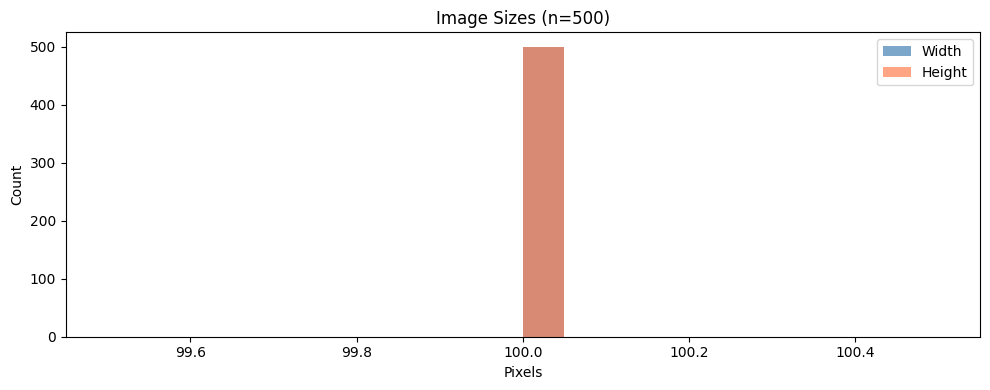

In [95]:
# check image sizes
widths, heights = [], []
for path, _ in train_dataset.samples[:500]:
    w, h = Image.open(path).size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(10, 4))
plt.hist(widths, bins=20, alpha=0.7, label='Width', color='steelblue')
plt.hist(heights, bins=20, alpha=0.7, label='Height', color='coral')
plt.title('Image Sizes (n=500)')
plt.xlabel('Pixels')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

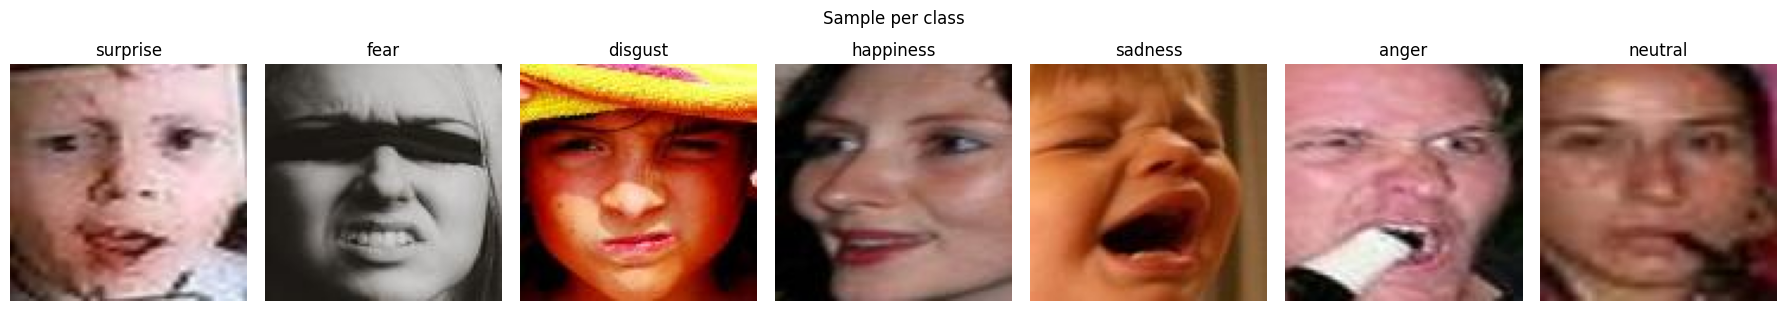

In [96]:
# Sample per Class
fig, axes = plt.subplots(1, 7, figsize=(18, 3))

seen = {}
for path, label in train_dataset.samples:
    if label not in seen:
        seen[label] = path
    if len(seen) == 7:
        break

for idx in range(7):
    img = Image.open(seen[idx]).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(LABEL_MAP[idx])
    axes[idx].axis('off')

plt.suptitle('Sample per class', y=1.02)
plt.tight_layout()
plt.show()

In [97]:
# load one sample from train_dataset
image, label = train_dataset[0]
print(type(image))
print(label)


<class 'torch.Tensor'>
0


Emotion       Count    Share
----------------------------
surprise       1290    10.5%
fear            281     2.3%
disgust         717     5.8%
happiness      4772    38.9%
sadness        1982    16.2%
anger           705     5.7%
neutral        2524    20.6%


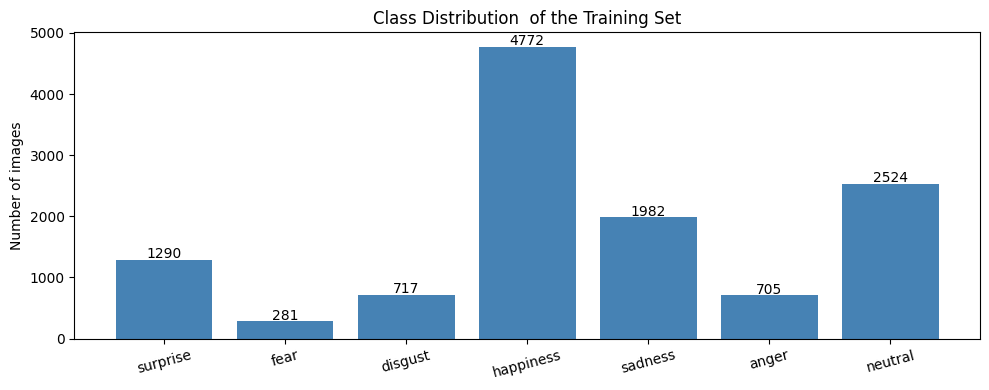

In [98]:
# class distribution
# used for cross entropy weighted classes
# the distribution of the classes was known before
counts = {i: 0 for i in range(7)}
for _, label in train_dataset.samples:
    counts[label] += 1

total = sum(counts.values())
print(f"{'Emotion':<12} {'Count':>6} {'Share':>8}")
print("-" * 28)
for label_idx, count in counts.items():
    print(f"{LABEL_MAP[label_idx]:<12} {count:>6} {count/total*100:>7.1f}%")

# plot
plt.figure(figsize=(10, 4))
bars = plt.bar([LABEL_MAP[i] for i in range(7)], counts.values(), color='steelblue')
plt.title('Class Distribution  of the Training Set')
plt.ylabel('Number of images')
plt.xticks(rotation=15)
for bar, count in zip(bars, counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Model

In [99]:
class Model:
    """
    Model class for facial emotion recognition.
    """
    def __init__(self, num_classes=7, model_version='v2'):
        """
        Initialize model parameters.
        Args:
            num_classes: Number of output classes.
            model_version: Model version (default is 'v2').
        """
        self.num_classes = num_classes
        self.model_version = model_version
        self.model = self.build_model()

    def build_model(self):
        """
        Build the model based on the specified model.
        Returns the model architecture.

        models:
        MobileNetV2, MobileNetV3, Resnet18, Resnet50, EfficientNet
        """
        # MobileNet Versions v2,v3 small, v3 large
        if self.model_version == 'v2':
            model = models.mobilenet_v2(weights='IMAGENET1K_V1')
            in_features = model.classifier[1].in_features
            model.classifier[1] = nn.Linear(in_features, self.num_classes)
        elif self.model_version == 'v3_small':
            model = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
            in_features = model.classifier[3].in_features
            model.classifier[3] = nn.Linear(in_features, self.num_classes)
        elif self.model_version == 'v3_large':
            model = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
            in_features = model.classifier[3].in_features
            model.classifier[3] = nn.Linear(in_features, self.num_classes)

        # Resnet 18, Resnet 50 models, EfficientNet
        elif self.model_version == 'resnet18':
            model = models.resnet18(weights='IMAGENET1K_V1')
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, self.num_classes)
        elif self.model_version == 'resnet50':
            model = models.resnet50(weights='IMAGENET1K_V1')
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, self.num_classes)

        elif self.model_version == 'efficientnet_b0':
            # EfficientNets classifier is a sequential layer, the last linear
            # https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b0.html
            model = models.efficientnet_b0(weights='IMAGENET1K_V1')
            in_features = model.classifier[1].in_features
            model.classifier[1] = nn.Linear(in_features, self.num_classes)
        else:
            raise ValueError(f"model not supported {self.model_version}")

        return model

    def freeze_base(self):
        """
        Freeze  base layers of the model, unfreeze only the classifier head.
        Uses model_version string instead of isinstance() checks as torchvision
        does not export MobileNetV2/V3 as public classes.
        """
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze the correct classifier head based on the chosen architecture
        if self.model_version in ('v2', 'v3_small', 'v3_large', 'efficientnet_b0'):
            for param in self.model.classifier.parameters():
                param.requires_grad = True
        elif self.model_version in ('resnet18', 'resnet50'):
            for param in self.model.fc.parameters():
                param.requires_grad = True

    def fine_tune(self):
        """
        Unfreeze all layers of the model for full fine-tuning.
        """
        for param in self.model.parameters():
            param.requires_grad = True

    def get_model(self):
        return self.model


# Trainer


Get the weights from the training data

In [100]:
class Trainer:
    """
    Trainer class for training the model.
    """
    def __init__(self, model, train_loader, val_loader, device, class_weights):
        """
        Initialize trainer parameters.
        Args:
            model: The model to be trained.
            train_loader: DataLoader for training data.
            val_loader: DataLoader for validation data.
            device: The device used for training.
            class_weights: Tensor of per-class weights for CrossEntropyLoss.
        """
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device

        self.criterion = torch.nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=0.1
        )

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=1e-3
        )

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='max',
            factor=0.5,
            patience=2
        )

        self.best_val_acc = -float('inf')
        self.epochs_no_improve = 0
        self.early_stop_patience = 5
        self.best_model_weights = None

        self.evaluator = Evaluator(self.model, self.val_loader, self.device)

    def train(self, epochs):
        """
        Train the model for the specified number of epochs.
        Args:
            epochs: Number of training epochs.
        """
        self.model.to(self.device)

        for epoch in range(epochs):

            self.model.train()
            total_loss = 0
            correct = 0
            total = 0

            for images, labels in self.train_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.item()
                predicted = outputs.argmax(dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

            train_acc = correct / total * 100
            avg_loss = total_loss / len(self.train_loader)
            val_acc = self.evaluator.evaluate()

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {avg_loss:.3f} | "
                f"Train Acc: {train_acc:.1f}% | "
                f"Val Acc: {val_acc:.1f}% | "
                f"No improve: {self.epochs_no_improve}/{self.early_stop_patience}"
            )

            mlflow.log_metric("train_loss", avg_loss, step=epoch)
            mlflow.log_metric("train_accuracy", train_acc, step=epoch)
            mlflow.log_metric("val_accuracy", val_acc, step=epoch)
            mlflow.log_metric("learning_rate", self.optimizer.param_groups[0]['lr'], step=epoch)

            self.scheduler.step(val_acc)

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.epochs_no_improve = 0
                self.best_model_weights = copy.deepcopy(self.model.state_dict())
            else:
                self.epochs_no_improve += 1

            if self.epochs_no_improve >= self.early_stop_patience:
                print("Early stopped")
                break

        # restore best weights
        self.model.load_state_dict(self.best_model_weights)
        print(f"Restored best weights with val acc: {self.best_val_acc:.1f}%")

# Evaluator

In [101]:
class Evaluator:
    """
    Evaluator class for evaluating the model.
    """
    def __init__(self, model, val_loader, device):
        """
        Initialize evaluator parameters.
        Args:
            model: The model to be evaluated.
            val_loader: DataLoader for validation data.
            device: The device CPU or GPU for evaluation.
        """
        self.model = model
        self.val_loader = val_loader
        self.device = device

    def _map_to_sentiment(self, label):
        return {'positive': 0, 'neutral': 1, 'negative': 2}[SENTIMENT_MAP[label]]

    def evaluate(self):
        """
        Evaluate the model on the validation set with f1scor, confusion matrix
        Returns accuracy.
        """
        self.model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(images)
                predicted = outputs.argmax(dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        accuracy = (correct / total * 100) if total > 0 else 0
        return accuracy

    # f1score
    def f1_score(self):
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                preds = outputs.argmax(dim=1).cpu()
                all_preds.extend(preds.numpy())
                all_labels.extend(labels.numpy())

        score = f1_score(all_labels, all_preds, average='weighted')
        print(f" Weighted F1 Score: {score:.3f}")
        return score

    # confusion matrix
    def confusion_matrix(self):
        self.model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                preds = outputs.argmax(dim=1).cpu()
                all_preds.extend(preds.numpy())
                all_labels.extend(labels.numpy())

        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=list(LABEL_MAP.values())
        )
        fig, ax = plt.subplots(figsize=(9, 7))
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        plt.title('Confusion Matrix on Test Set')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

    def evaluate_sentiment(self):
        """
        Evaluate the model on the val set with the sentiment
        labels positive, neutral, negative
        Returns accuracy.
        """
        self.model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                preds = self.model(images).argmax(dim=1)
                pred_s = torch.tensor([self._map_to_sentiment(p.item()) for p in preds])
                true_s = torch.tensor([self._map_to_sentiment(l.item()) for l in labels])
                correct += (pred_s == true_s).sum().item()
                total += labels.size(0)

        acc = correct / total * 100
        print(f"Sentiment Accuracy: {acc:.1f}%")
        return acc

    # confusion matrix for 3 sentiment classes
    def confusion_matrix_sentiment(self):
        self.model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for images, labels in self.val_loader:
                images = images.to(self.device)
                preds = self.model(images).argmax(dim=1).cpu()
                all_preds.extend([self._map_to_sentiment(p.item()) for p in preds])
                all_labels.extend([self._map_to_sentiment(l.item()) for l in labels])

        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(cm, display_labels=SENTIMENT_LABELS)
        fig, ax = plt.subplots(figsize=(6, 5))
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        plt.title('Confusion Matrix on Sentiment 3 Classes')
        plt.tight_layout()
        plt.show()

# Training

In [102]:
# apply data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [103]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [104]:
# weights for the training data
counts = {i: 0 for i in range(7)}
for _, label in train_dataset.samples:
    counts[label] += 1

total = sum(counts.values())
weights = [total / counts[i] for i in range(7)]

# normalise so that the sum is 7
weights_sum = sum(weights)
weights = [w / weights_sum * 7 for w in weights]
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(class_weights)

tensor([0.6572, 3.0168, 1.1823, 0.1776, 0.4277, 1.2025, 0.3359],
       device='cuda:0')


Setup complete. Starting training
Epoch 1/5 | Loss: 2.033 | Train Acc: 26.5% | Val Acc: 31.9% | No improve: 0/5
Epoch 2/5 | Loss: 1.949 | Train Acc: 34.3% | Val Acc: 44.0% | No improve: 0/5
Epoch 3/5 | Loss: 1.911 | Train Acc: 37.8% | Val Acc: 43.7% | No improve: 0/5
Epoch 4/5 | Loss: 1.896 | Train Acc: 37.2% | Val Acc: 28.4% | No improve: 1/5
Epoch 5/5 | Loss: 1.899 | Train Acc: 38.0% | Val Acc: 42.3% | No improve: 2/5
Restored best weights with val acc: 44.0%
Unfreezing for fine tuning
Epoch 1/20 | Loss: 1.737 | Train Acc: 48.8% | Val Acc: 52.6% | No improve: 0/5
Epoch 2/20 | Loss: 1.551 | Train Acc: 58.9% | Val Acc: 57.6% | No improve: 0/5
Epoch 3/20 | Loss: 1.422 | Train Acc: 65.8% | Val Acc: 65.5% | No improve: 0/5
Epoch 4/20 | Loss: 1.334 | Train Acc: 70.7% | Val Acc: 69.7% | No improve: 0/5
Epoch 5/20 | Loss: 1.265 | Train Acc: 73.9% | Val Acc: 68.3% | No improve: 0/5
Epoch 6/20 | Loss: 1.202 | Train Acc: 77.4% | Val Acc: 71.7% | No improve: 1/5
Epoch 7/20 | Loss: 1.145 | Train 

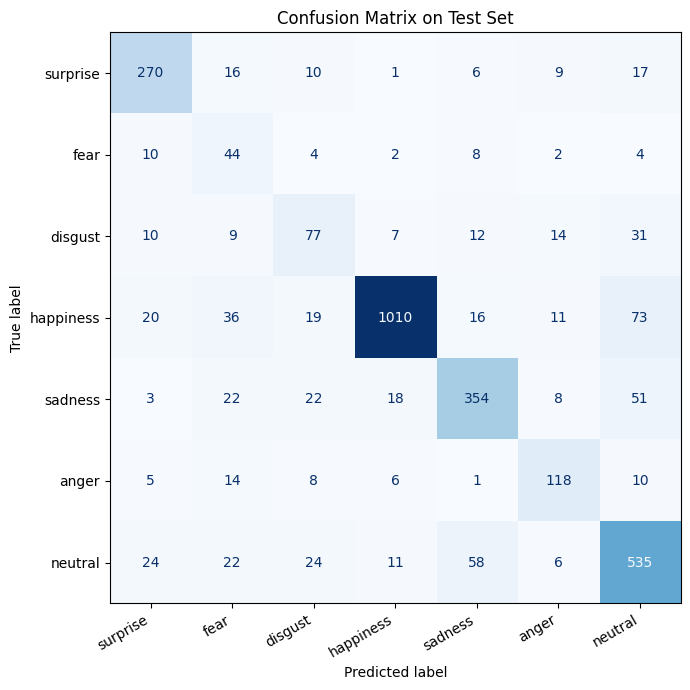

 Weighted F1 Score: 0.794
Sentiment Accuracy: 83.2%


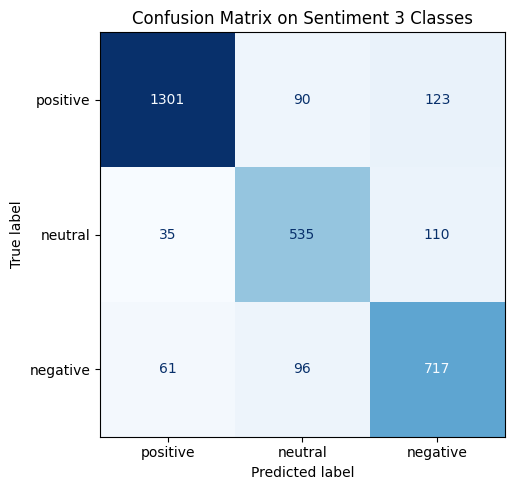

Model saved to emotion_model.pth


In [106]:
# model setup
mlflow.end_run()
model_wrapper = Model(num_classes=7, model_version='resnet50')

# freeze base layers
model_wrapper.freeze_base()

# torch model
model = model_wrapper.get_model()

# initialize the trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    class_weights=class_weights
)

print("Setup complete. Starting training")

# using mlflow to trake
with mlflow.start_run():
    mlflow.log_param("model", model_wrapper.model_version)
    mlflow.log_param("batch_size", train_loader.batch_size)
    mlflow.log_param("label_smoothing", trainer.criterion.label_smoothing)

    # Start training for 5 epochs
    trainer.train(epochs=5)

    # Fine Tuning
    print("Unfreezing for fine tuning")
    model_wrapper.fine_tune()

    # reset early stopping, scheduler
    trainer.best_val_acc = -float('inf')
    trainer.epochs_no_improve = 0

    for param_group in trainer.optimizer.param_groups:
        param_group['lr'] = 1e-5

    trainer.train(epochs=20)

    # evaluator
    evaluator = Evaluator(model, val_loader, device)

    # evaluate 7 emotion classes
    evaluator.confusion_matrix()
    evaluator.f1_score()

    # evaluate 3 sentiment classes
    evaluator.evaluate_sentiment()
    evaluator.confusion_matrix_sentiment()

    # save the trained model weights
    torch.save(model.state_dict(), 'emotion_model.pth')
    print("Model saved to emotion_model.pth")

## Visualize Predictions

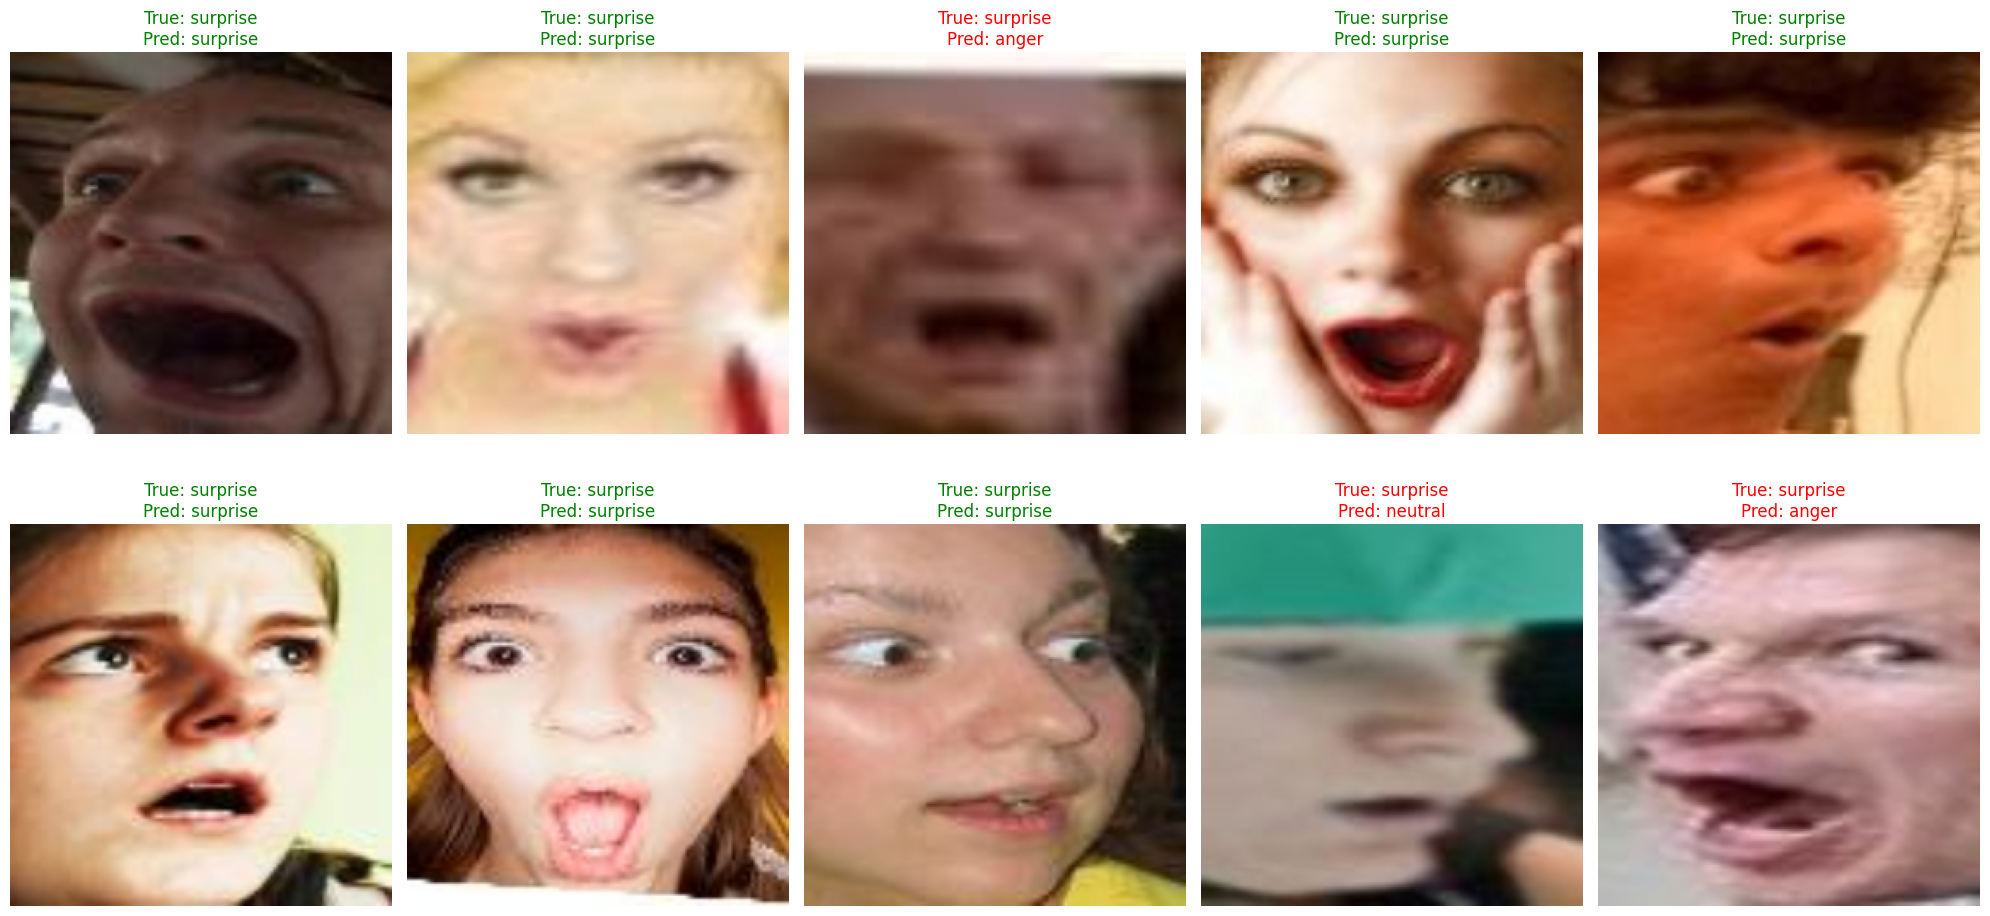

In [107]:
def visualize_predictions(trainer, class_names, num_images=10):
    """
    Visualize Samples of Prediction with surprise class

    args:
        trainer: Trainer object
        class_names: List of class names
        num_images: Number of images to visualize
    """
    trainer.model.eval()
    images_shown = 0
    plt.figure(figsize=(20, 10))

    # batch from the validation loader
    with torch.no_grad():
        for images, labels in trainer.val_loader:
            images_cuda = images.to(trainer.device)
            outputs = trainer.model(images_cuda)
            preds = outputs.argmax(dim=1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    break

                # Denormalize
                img = images[i].permute(1, 2, 0).numpy()
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax = plt.subplot(2, 5, images_shown + 1)
                plt.imshow(img)

                true_label = class_names[labels[i]]
                pred_label = class_names[preds[i]]
                color = 'green' if true_label == pred_label else 'red'

                plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
                plt.axis('off')
                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()

# emotion labels
emotion_labels = ['surprise', 'fear', 'disgust', 'happiness', 'sadness', 'anger', 'neutral']

# 10 samples from the test/validation set
visualize_predictions(trainer, emotion_labels, num_images=10)


In [108]:
runs = mlflow.search_runs()
print(runs[["run_id", "metrics.train_loss", "metrics.train_accuracy", "metrics.val_accuracy", "params.model"]])

                             run_id  metrics.train_loss  \
0  7ec19eabe54440c683beb345f7ba9b7d            0.857798   
1  1e8d4c0b78d949e7a7c903a87efe90fd                 NaN   
2  d6977dcd1a124e6fb473890f8ab041e8            1.023276   
3  5828280a39314559811962c7ddf87d76            1.265557   
4  75c87a29274c4ab0b18392c5b27b0892            0.893395   
5  e1a133c036ba41ac8f91a1932b0f988c            1.912553   

   metrics.train_accuracy  metrics.val_accuracy params.model  
0               96.829924             78.487614     resnet50  
1                     NaN                   NaN     resnet50  
2               86.838888             74.869622     resnet50  
3               74.500856             70.664928     resnet50  
4               95.452693             76.531943     resnet50  
5               37.364518             32.790091         None  


# Gradio Interface
The model can be used with a temporary web interface with gradio. The notebook gradio_interface_demo can be run using the model weights:
https://colab.research.google.com/github/cewgs/Computer-Vision-Project/blob/main/gradio_interface_demo.ipynb

In [113]:
# Gradio Interface
# https://www.gradio.app/guides/quickstart
# just for demonstration

# Labels
LABEL_MAP = {
    0: "surprise", 1: "fear", 2: "disgust",
    3: "happiness", 4: "sadness", 5: "anger", 6: "neutral"
}

SENTIMENT_MAP = {
    0: "positive", 1: "negative", 2: "negative",
    3: "positive", 4: "negative", 5: "negative", 6: "neutral"
}

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(torch.load("emotion_model.pth", map_location=device))
model.to(device)
model.eval()

# Preprocessing as for val transform in notebook
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Predict function for gradio
def predict(image):
    """
    create prediction function and using softmax to get probabilities
    Args:
        image: PIL image
    """
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).squeeze()

    # dict for label and probabilties
    scores = {LABEL_MAP[i]: float(probs[i]) for i in range(7)}

    top_idx = probs.argmax().item()
    sentiment = SENTIMENT_MAP[top_idx]

    label = f"{LABEL_MAP[top_idx].upper()}  Sentiment: {sentiment}"
    return label, scores

# Gradio interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Text(label="Prediction"),
        gr.Label(label="Emotion probabilities", num_top_classes=7)
    ],
    title="Facial Emotion Recognizer",
    description="Upload a photo of a face to detect the emotion."
)

# demo.launch()